In [1]:
pip install transformers shap datasets

In [2]:
import datasets
import numpy as np
import transformers
import shap

In [3]:
dataset = datasets.load_dataset("imdb", split="test")

# shorten the strings to fit into the pipeline model
short_data = [v[:500] for v in dataset["text"][:20]]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [4]:
print(dataset[0])

{'text': 'I love sci-fi and am willing to put up with a lot. Sci-fi movies/TV are usually underfunded, under-appreciated and misunderstood. I tried to like this, I really did, but it is to good TV sci-fi as Babylon 5 is to Star Trek (the original). Silly prosthetics, cheap cardboard sets, stilted dialogues, CG that doesn\'t match the background, and painfully one-dimensional characters cannot be overcome with a \'sci-fi\' setting. (I\'m sure there are those of you out there who think Babylon 5 is good sci-fi TV. It\'s not. It\'s clichéd and uninspiring.) While US viewers might like emotion and character development, sci-fi is a genre that does not take itself seriously (cf. Star Trek). It may treat important issues, yet not as a serious philosophy. It\'s really difficult to care about the characters here as they are not simply foolish, just missing a spark of life. Their actions and reactions are wooden and predictable, often painful to watch. The makers of Earth KNOW it\'s rubbish as 

In [5]:
print(short_data[0])

I love sci-fi and am willing to put up with a lot. Sci-fi movies/TV are usually underfunded, under-appreciated and misunderstood. I tried to like this, I really did, but it is to good TV sci-fi as Babylon 5 is to Star Trek (the original). Silly prosthetics, cheap cardboard sets, stilted dialogues, CG that doesn't match the background, and painfully one-dimensional characters cannot be overcome with a 'sci-fi' setting. (I'm sure there are those of you out there who think Babylon 5 is good sci-fi 


In [6]:
import pandas as pd

# Create a pandas dataframe
df = pd.DataFrame(short_data)

# Display the head of the dataframe
print(df)

                                                    0
0   I love sci-fi and am willing to put up with a ...
1   Worth the entertainment value of a rental, esp...
2   its a totally average film with a few semi-alr...
3   STAR RATING: ***** Saturday Night **** Friday ...
4   First off let me say, If you haven't enjoyed a...
5   I had high hopes for this one until they chang...
6   Isaac Florentine has made some of the best wes...
7   It actually pains me to say it, but this movie...
8   Technically I'am a Van Damme Fan, or I was. th...
9   Honestly awful film, bad editing, awful lighti...
10  This flick is a waste of time.I expect from an...
11  Blind Date (Columbia Pictures, 1934), was a de...
12  I first watched this movie back in the mid/lat...
13  I saw the Mogul Video VHS of this. That's anot...
14  A group of heirs to a mysterious old mansion f...
15  Now, I LOVE Italian horror films. The cheesier...
16  This cheap, grainy-filmed Italian flick is abo...
17  I just finished watching

In [7]:
classifier = transformers.pipeline("sentiment-analysis", return_all_scores=True)

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [8]:
# Example texts for sentiment analysis
texts = ["I love this movie! It was the best movie of all time", "I liked the first half but did not like the second half."]

# Perform sentiment analysis
results = classifier(texts)

print(results)

[{'label': 'POSITIVE', 'score': 0.9998692274093628}, {'label': 'NEGATIVE', 'score': 0.9635261297225952}]


In [9]:
print("1: ", short_data[0],"\n")
print("2: ", short_data[1],"\n")
print("3: ",short_data[2],"\n")
print("\n")
print(classifier(short_data[:3]))

1:  I love sci-fi and am willing to put up with a lot. Sci-fi movies/TV are usually underfunded, under-appreciated and misunderstood. I tried to like this, I really did, but it is to good TV sci-fi as Babylon 5 is to Star Trek (the original). Silly prosthetics, cheap cardboard sets, stilted dialogues, CG that doesn't match the background, and painfully one-dimensional characters cannot be overcome with a 'sci-fi' setting. (I'm sure there are those of you out there who think Babylon 5 is good sci-fi  

2:  Worth the entertainment value of a rental, especially if you like action movies. This one features the usual car chases, fights with the great Van Damme kick style, shooting battles with the 40 shell load shotgun, and even terrorist style bombs. All of this is entertaining and competently handled but there is nothing that really blows you away if you've seen your share before.<br /><br />The plot is made interesting by the inclusion of a rabbit, which is clever but hardly profound. Ma

In [10]:
from sklearn.metrics import accuracy_score

# Predict the sentiment for the short data
predictions = classifier(short_data)

# Convert the predictions to labels
predicted_labels = []
for prediction in predictions:
    # Corrected line: Directly access the 'label' from the prediction dictionary
    predicted_label = prediction['label']
    predicted_labels.append(0 if predicted_label == 'NEGATIVE' else 1)  # Assuming 'NEGATIVE' is 0 and 'POSITIVE' is 1

true_labels = dataset["label"][:20]  # Get the true labels

# Calculate the accuracy
accuracy = accuracy_score(true_labels, predicted_labels)
print(f"Accuracy: {accuracy}")

print(true_labels)

print(predicted_labels)

Accuracy: 0.8
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [11]:
print(dataset[12500])

{'text': "Previous reviewer Claudio Carvalho gave a much better recap of the film's plot details than I could. What I recall mostly is that it was just so beautiful, in every sense - emotionally, visually, editorially - just gorgeous.<br /><br />If you like movies that are wonderful to look at, and also have emotional content to which that beauty is relevant, I think you will be glad to have seen this extraordinary and unusual work of art.<br /><br />On a scale of 1 to 10, I'd give it about an 8.75. The only reason I shy away from 9 is that it is a mood piece. If you are in the mood for a really artistic, very romantic film, then it's a 10. I definitely think it's a must-see, but none of us can be in that mood all the time, so, overall, 8.75.", 'label': 1}


In [12]:
# define the explainer
explainer = shap.Explainer(classifier)

In [13]:
# explain the predictions of the pipeline on the first two samples
shap_values = explainer(short_data[:2])

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  50%|█████     | 1/2 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 3it [04:25, 132.57s/it]


In [14]:
print(shap_values.shape)

(2, None, 2)


In [15]:
pmodel = shap.models.TransformersPipeline(classifier, rescale_to_logits=False)

In [16]:
pmodel(short_data[:2])

array([[0.        , 0.92417908],
       [0.        , 0.98165751]])

In [17]:
pmodel = shap.models.TransformersPipeline(classifier, rescale_to_logits=True)
pmodel(short_data[:2])

array([[0.        , 2.50053158],
       [0.        , 3.98002198]])

In [18]:
explainer2 = shap.Explainer(pmodel)
shap_values2 = explainer2(short_data[:2])
shap.plots.text(shap_values2[:, :, 1])

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  50%|█████     | 1/2 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 3it [04:10, 125.37s/it]


In [19]:
masker = shap.maskers.Text(classifier.tokenizer)
explainer3 = shap.Explainer(pmodel, masker)
shap_values3 = explainer3(short_data[:2])
shap.plots.text(shap_values3[:, :, 1])

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  50%|█████     | 1/2 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 3it [04:12, 126.07s/it]


In [20]:
masker = shap.maskers.Text(classifier.tokenizer)
explainer2 = shap.Explainer(pmodel, masker)
shap_values2 = explainer2(short_data[:2])
shap.plots.text(shap_values2[:, :, 1])

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  50%|█████     | 1/2 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 3it [04:10, 125.46s/it]


In [21]:
masker.shape("I like this movie.")

(1, 7)

In [22]:
model_args = masker(
    np.array([True, True, True, True, True, True, True]), "I like this movie."
)
model_args

(array(['I like this movie.'], dtype='<U18'),)

In [23]:
pmodel(*model_args)

array([[0.        , 8.90786191]])

In [24]:
model_args = masker(
    np.array([True, True, False, False, True, True, True]), "I like this movie."
)
model_args

(array(['I [MASK] [MASK]movie.'], dtype='<U21'),)

In [25]:
pmodel(*model_args)

array([[0.        , 3.72091284]])

In [26]:
masker2 = shap.maskers.Text(
    classifier.tokenizer, mask_token="...", collapse_mask_token=True
)

In [27]:
model_args2 = masker2(
    np.array([True, True, False, False, True, True, True]), "I like this movie."
)
model_args2

(array(['I ...movie.'], dtype='<U11'),)

In [28]:
pmodel(*model_args2)

array([[0.        , 3.20817796]])

In [29]:
# explain the predictions of the pipeline on the first two samples
shap_values = explainer(short_data[:20])

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:   5%|▌         | 1/20 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  15%|█▌        | 3/20 [04:10<16:21, 57.71s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

...

PartitionExplainer explainer:  95%|█████████▌| 19/20 [38:46<02:06, 126.47s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 20/20 [41:07<00:00, 130.87s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 21it [43:39, 130.96s/it]


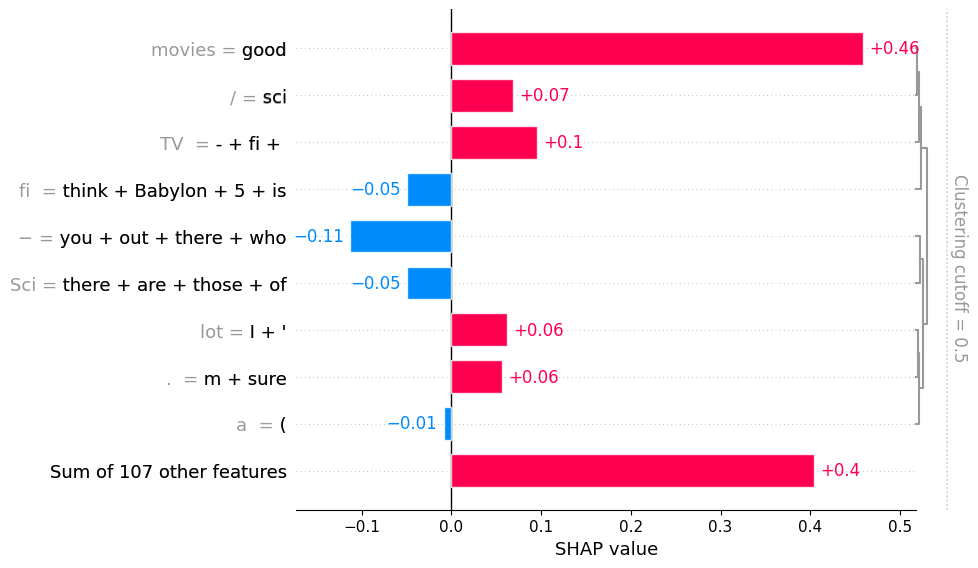

In [30]:
shap.plots.bar(shap_values[0, :, "POSITIVE"])

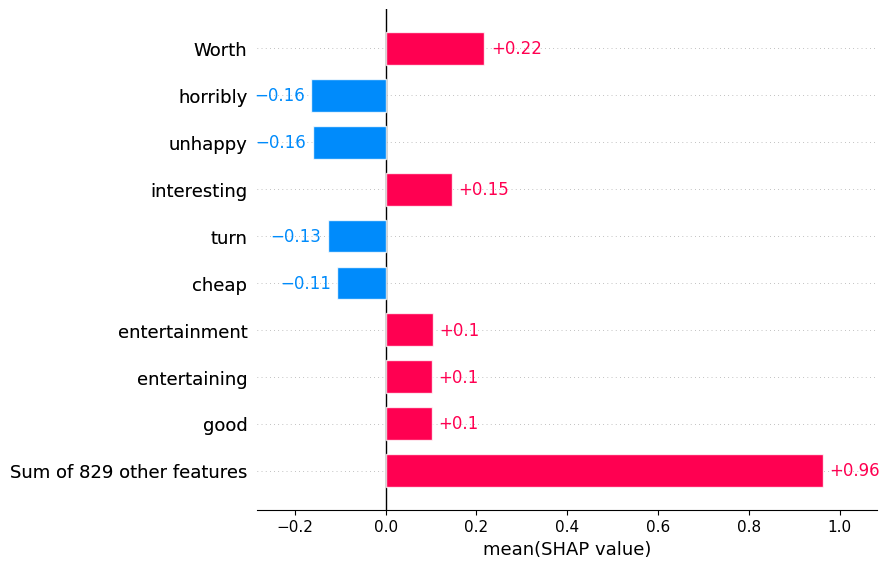

In [31]:
shap.plots.bar(shap_values[:, :, "POSITIVE"].mean(0))

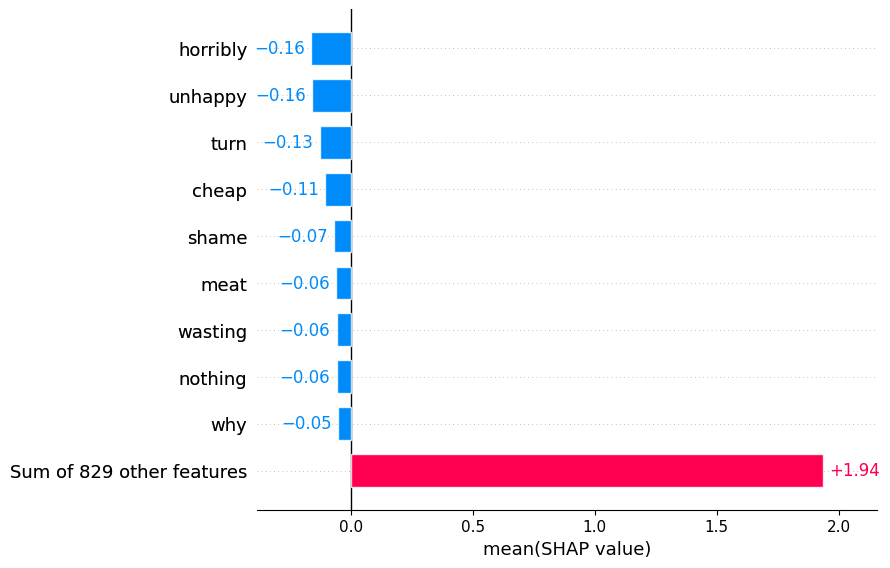

In [32]:
shap.plots.bar(shap_values[:, :, "POSITIVE"].mean(0), order=shap.Explanation.argsort)

In [ ]:
import nbformat
import os

def clean_notebook_metadata(notebook_path):
    try:
        with open(notebook_path, 'r', encoding='utf-8') as f:
            notebook_content = nbformat.read(f, as_version=4)

        if 'widgets' in notebook_content.metadata:
            print(f"Removing 'widgets' from metadata of {notebook_path}")
            del notebook_content.metadata['widgets']
            with open(notebook_path, 'w', encoding='utf-8') as f:
                nbformat.write(notebook_content, f)
            print(f"Successfully cleaned metadata for {notebook_path}")
        else:
            print(f"'widgets' key not found in metadata for {notebook_path}. No action needed.")

    except Exception as e:
        print(f"An error occurred: {e}")

# The user explicitly provided the notebook filename
notebook_path = 'Lime for Image data.ipynb'

if os.path.exists(notebook_path):
    clean_notebook_metadata(notebook_path)
else:
    print(f"Error: The specified notebook file '{notebook_path}' does not exist in the current directory. Please ensure it is uploaded.")